# SFT Baseline: NanoVLM + MiniGrid EmptyEnv

Пайплайн дообучения vision-language модели для управления агентом.

- **Эксперт:** greedy shortest-path (оптимален для EmptyEnv без препятствий)
- **Данные:** `MiniGrid-Empty-6x6-v0`
- **Оценка:** 6x6 (in-distribution) и 16x16 (out-of-distribution, для сравнения с GRPO)

In [1]:
!pip install -q gymnasium minigrid torch torchvision pillow tqdm matplotlib transformers huggingface-hub safetensors
!test -d nanoVLM || git clone --branch v0.1 --depth 1 https://github.com/huggingface/nanoVLM.git

import sys
sys.path.insert(0, "nanoVLM")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 76.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 require

In [2]:
import json
import random
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import minigrid
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from data.processors import get_image_processor, get_tokenizer
from models.config import VLMConfig
from models.vision_language_model import VisionLanguageModel

MODEL_ID = "lusxvr/nanoVLM-222M"
TRAIN_ENV = "MiniGrid-Empty-6x6-v0"
EVAL_ENVS = ["MiniGrid-Empty-6x6-v0", "MiniGrid-Empty-16x16-v0"]
N_EPISODES = 200
MAX_STEPS = 100
EPOCHS = 3
BATCH_SIZE = 8
LR = 5e-5
MAX_SEQ_LEN = 128
SEED = 42
OUTPUT_DIR = Path("/kaggle/working/sft_baseline")

USE_BALANCED_DATA = False
USE_CURRICULUM_8x8 = False

PROMPT = (
    "Question: You are a navigation agent in a grid world. "
    "Choose the next action: 0=left, 1=right, 2=forward. Answer:"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Expert Data Collection

Эксперт — **greedy shortest-path**: сначала выравниваем колонку (x), затем строку (y).
В EmptyEnv без препятствий это оптимальная политика с 100% success rate.

In [3]:
def find_goal(env):
    for x in range(env.width):
        for y in range(env.height):
            cell = env.grid.get(x, y)
            if cell is not None and cell.type == "goal":
                return (x, y)
    raise RuntimeError("Goal not found")


def get_expert_action(env):
    """Greedy shortest-path"""
    agent_pos = env.agent_pos
    agent_dir = env.agent_dir  # 0=right, 1=down, 2=left, 3=up
    goal_pos = find_goal(env)
    ax, ay = agent_pos
    gx, gy = goal_pos

    if ax != gx:
        desired_dir = 0 if gx > ax else 2
    elif ay != gy:
        desired_dir = 1 if gy > ay else 3
    else:
        return 2

    if agent_dir == desired_dir:
        return 2  # forward
    diff = (desired_dir - agent_dir) % 4
    return 1 if diff == 1 else 0  # right or left


def collect_expert_rollouts(env_id, n_episodes, max_steps, seed=0):
    """Собирает (image, action) пары из экспертных траекторий."""
    env = gym.make(env_id, render_mode="rgb_array")
    samples = []
    action_counts = {0: 0, 1: 0, 2: 0}

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        for _ in range(max_steps):
            rgb = env.render()
            image = Image.fromarray(rgb)
            action = get_expert_action(env.unwrapped)
            samples.append({"image": image, "action": action})
            action_counts[action] += 1
            obs, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                break
    env.close()
    print(f"  {env_id}: {len(samples)} steps, actions: {action_counts}")
    return samples


def balance_turn_actions(samples, oversample_factor=3):
    """Upsampling поворотов"""
    turns = [s for s in samples if s["action"] in (0, 1)]
    forwards = [s for s in samples if s["action"] == 2]
    extra = turns * (oversample_factor - 1)
    balanced = forwards + turns + extra
    random.shuffle(balanced)
    print(f"  Balanced: {len(forwards)} forward + {len(turns) + len(extra)} turns = {len(balanced)} total")
    return balanced


print("Collecting expert data...")
raw_samples = collect_expert_rollouts(TRAIN_ENV, N_EPISODES, MAX_STEPS, seed=SEED)

if USE_CURRICULUM_8x8:
    extra = collect_expert_rollouts("MiniGrid-Empty-8x8-v0", N_EPISODES // 2, MAX_STEPS, seed=SEED + 1000)
    raw_samples.extend(extra)

if USE_BALANCED_DATA:
    raw_samples = balance_turn_actions(raw_samples)

print(f"Total samples: {len(raw_samples)}")

  MiniGrid-Empty-6x6-v0: 1400 steps, actions: {0: 0, 1: 200, 2: 1200}
Total samples: 1400


## 3. Dataset & Collator


In [4]:
tokenizer = get_tokenizer(VLMConfig.lm_tokenizer)
image_processor = get_image_processor(VLMConfig.vit_img_size)


class MiniGridCollator:
    """Collator для SFT: маскирует prompt, предсказывает только action-токены."""

    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        images = torch.stack([item["image"] for item in batch])
        texts = [item["text_data"] for item in batch]
        answers = [item["answer"] for item in batch]
        sequences = [f"{t}{a}" for t, a in zip(texts, answers)]

        encoded = self.tokenizer(
            sequences,
            padding="max_length",
            padding_side="left",
            return_tensors="pt",
            truncation=True,
            max_length=self.max_length,
        )
        input_ids = encoded["input_ids"]
        attention_mask = encoded["attention_mask"]
        labels = input_ids.clone()
        labels[:, :-1] = input_ids[:, 1:].clone()
        labels[:, -1] = -100

        original_lengths = [len(self.tokenizer.encode(seq)) for seq in sequences]
        for i in range(len(batch)):
            question_length = len(self.tokenizer.encode(texts[i], add_special_tokens=False))
            if original_lengths[i] > self.max_length:
                labels[i, :] = -100
                continue
            first_token_pos = attention_mask[i].nonzero(as_tuple=True)[0][0].item()
            question_end = first_token_pos + question_length - 1
            labels[i, :question_end] = -100

        return {
            "image": images,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }


class MiniGridSFTDataset(Dataset):
    def __init__(self, samples, prompt, tokenizer, image_processor):
        self.samples = samples
        self.prompt = prompt
        self.tokenizer = tokenizer
        self.image_processor = image_processor

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = sample["image"].convert("RGB")
        action_str = str(sample["action"])
        return {
            "image": self.image_processor(image),
            "text_data": self.prompt,
            "answer": action_str + self.tokenizer.eos_token,
        }


dataset = MiniGridSFTDataset(raw_samples, PROMPT, tokenizer, image_processor)
collator = MiniGridCollator(tokenizer, max_length=MAX_SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
print(f"Dataset: {len(dataset)} samples, {len(dataloader)} batches")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/489 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset: 1400 samples, 175 batches


## 4. Inference helpers

Функции для rollout в среде — нужны и при обучении (eval каждую эпоху), и для финальной оценки.

In [6]:
def parse_action(text):
    """Извлечь действие 0/1/2 из сгенерированного текста."""
    text = text.strip()
    for ch in text:
        if ch in "012":
            return int(ch)
    return 2


@torch.no_grad()
def predict_action(model, env, prompt, tokenizer, image_processor):
    """Предсказать действие по текущему кадру среды."""
    model.eval()
    rgb = env.render()
    image = Image.fromarray(rgb).convert("RGB")
    processed = image_processor(image).unsqueeze(0).to(device)
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    attention_mask = torch.ones_like(input_ids)

    generated = model.generate(input_ids, processed, attention_mask, max_new_tokens=3)
    answer = tokenizer.decode(generated[0], skip_special_tokens=True)
    model.train()
    return parse_action(answer)


def evaluate_policy(model, env_id, n_episodes=50, max_steps=100, seed=0):
    """Оценить политику: success rate и средний return."""
    env = gym.make(env_id, render_mode="rgb_array")
    successes, returns, lengths = 0, [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        for step in range(max_steps):
            action = predict_action(model, env, PROMPT, tokenizer, image_processor)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                if terminated and reward > 0:
                    successes += 1
                lengths.append(step + 1)
                break
        else:
            lengths.append(max_steps)
        returns.append(total_reward)

    env.close()
    return {
        "env_id": env_id,
        "success_rate": successes / n_episodes,
        "avg_return": np.mean(returns),
        "avg_length": np.mean(lengths),
    }

## 5. Training Loop



In [8]:
print(f"Loading model: {MODEL_ID}")
MAX_STEPS = 40
model = VisionLanguageModel.from_pretrained(MODEL_ID).to(device)
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
train_losses = []
epoch_eval_history = {env_id: [] for env_id in EVAL_ENVS}

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch + 1}/{EPOCHS}")
    for batch in pbar:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        _, loss = model(input_ids, images, attention_mask, targets=labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        step_loss = loss.item()
        epoch_loss += step_loss
        train_losses.append(step_loss)
        pbar.set_postfix(loss=f"{step_loss:.4f}")

    avg = epoch_loss / len(dataloader)
    print(f"Epoch {epoch + 1} avg loss: {avg:.4f}")

    for env_id in EVAL_ENVS:
        r = evaluate_policy(model, env_id, n_episodes=30, max_steps=MAX_STEPS, seed=SEED)
        epoch_eval_history[env_id].append(r["success_rate"])
        print(f"  eval {env_id}: success={r['success_rate']:.1%}")

Loading model: lusxvr/nanoVLM-222M


Epoch 1/3:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 1 avg loss: 0.1451
  eval MiniGrid-Empty-6x6-v0: success=3.3%
  eval MiniGrid-Empty-16x16-v0: success=0.0%


Epoch 2/3:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 2 avg loss: 0.0000
  eval MiniGrid-Empty-6x6-v0: success=30.0%
  eval MiniGrid-Empty-16x16-v0: success=0.0%


Epoch 3/3:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 3 avg loss: 0.0000
  eval MiniGrid-Empty-6x6-v0: success=93.3%
  eval MiniGrid-Empty-16x16-v0: success=0.0%


## 6. Final Evaluation

Финальная оценка на 100 эпизодах.

In [9]:
MAX_STEPS = 100
eval_results = {}
for env_id in EVAL_ENVS:
    result = evaluate_policy(model, env_id, n_episodes=50, max_steps=MAX_STEPS, seed=SEED)
    eval_results[env_id] = result
    print(f"  {env_id}: success={result['success_rate']:.1%}, "
          f"return={result['avg_return']:.3f}, len={result['avg_length']:.1f}")

Final evaluation...
  MiniGrid-Empty-6x6-v0: success=100.0%, return=0.873, len=20.3
  MiniGrid-Empty-16x16-v0: success=6.0%, return=0.056, len=98.0


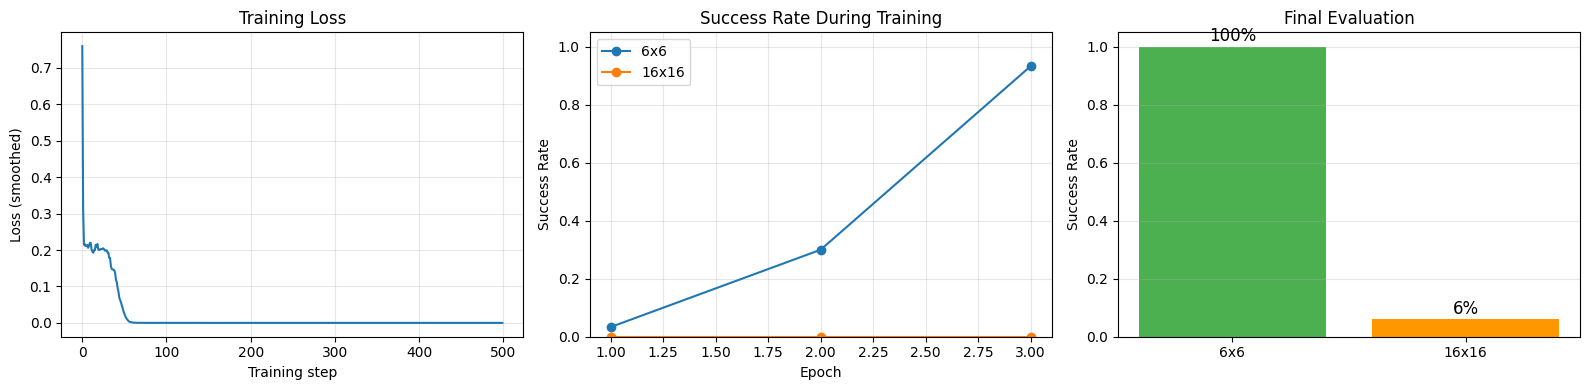

Plot saved to /kaggle/working/sft_baseline/learning_curves.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

window = max(1, len(train_losses) // 20)
smoothed = np.convolve(train_losses, np.ones(window) / window, mode="valid")
axes[0].plot(smoothed)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss (smoothed)")
axes[0].set_title("Training Loss")
axes[0].grid(True, alpha=0.3)

env_names = [e.replace("MiniGrid-Empty-", "").replace("-v0", "") for e in EVAL_ENVS]
success_rates = [eval_results[e]["success_rate"] for e in EVAL_ENVS]
epochs_x = list(range(1, EPOCHS + 1))
for env_id in EVAL_ENVS:
    label = env_id.replace("MiniGrid-Empty-", "").replace("-v0", "")
    axes[1].plot(epochs_x, epoch_eval_history[env_id], marker="o", label=label)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Success Rate")
axes[1].set_title("Success Rate During Training")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

bars = axes[2].bar(env_names, success_rates, color=["#4CAF50", "#FF9800"])
axes[2].set_ylabel("Success Rate")
axes[2].set_title("Final Evaluation")
axes[2].set_ylim(0, 1.05)
for bar, rate in zip(bars, success_rates):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{rate:.0%}", ha="center", fontsize=12)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves.png", dpi=150)
plt.show()
print(f"Plot saved to {OUTPUT_DIR / 'learning_curves.png'}")

In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(OUTPUT_DIR / "checkpoint"))

results = {
    "config": {
        "model_id": MODEL_ID,
        "train_env": TRAIN_ENV,
        "n_episodes": N_EPISODES,
        "epochs": EPOCHS,
        "lr": LR,
        "use_balanced_data": USE_BALANCED_DATA,
        "use_curriculum_8x8": USE_CURRICULUM_8x8,
    },
    "train_losses": train_losses,
    "epoch_eval_history": epoch_eval_history,
    "eval": {k: {kk: float(vv) if isinstance(vv, (np.floating, float)) else vv
                 for kk, vv in v.items()} for k, v in eval_results.items()},
}
with open(OUTPUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Checkpoint: {OUTPUT_DIR / 'checkpoint'}")
print(f"Results:    {OUTPUT_DIR / 'results.json'}")

Checkpoint: /kaggle/working/sft_baseline/checkpoint
Results:    /kaggle/working/sft_baseline/results.json


In [14]:
import os, zipfile, shutil

WORKING = "/kaggle/working/sft_baseline"
ARCHIVE = "/kaggle/working/sft_baseline_res0.zip"

TO_PACK = [
    "checkpoint/config.json",
    "checkpoint/model.safetensors",
    "results.json",
    "learning_curves.png",
]

README = """sft_baseline
"""

with zipfile.ZipFile(ARCHIVE, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("README_STAGE2.txt", README)
    for rel in TO_PACK:
        path = os.path.join(WORKING, rel)
        if os.path.isfile(path):
            zf.write(path, arcname=rel)
            print(f"  + {rel}")
        else:
            print(f"  - skip (missing): {rel}")

size_mb = os.path.getsize(ARCHIVE) / 1024 / 1024
print(f"\nArchive ready: {ARCHIVE} ({size_mb:.0f} MB)")


  + checkpoint/config.json
  + checkpoint/model.safetensors
  + results.json
  + learning_curves.png

Archive ready: /kaggle/working/sft_baseline_res0.zip (787 MB)
Download: Kaggle → Output → sft_stage2_bundle.zip
Then: Save Version (Commit) so Output persists after session ends!


In [21]:
import json
import shutil
from pathlib import Path

DATASET_NAME = "sft-baseline_res"
USERNAME = "gleror"

dataset_dir = Path("/kaggle/working/dataset_for_kaggle")
dataset_dir.mkdir(exist_ok=True)

shutil.copy(
    "/kaggle/working/sft_baseline_res0.zip",
    dataset_dir / "sft_baseline_res0.zip"
)

metadata = {
    "title": "sft-baseline-res",
    "id": f"{USERNAME}/sft-baseline-res",
    "licenses": [{"name": "CC0-1.0"}],
    "isPrivate": True
}

with open(dataset_dir / "dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Dataset folder prepared:", dataset_dir)

Dataset folder prepared: /kaggle/working/dataset_for_kaggle


In [22]:
!kaggle datasets create \
    -p /kaggle/working/dataset_for_kaggle \
    --dir-mode zip

Starting upload for file sft_baseline_res0.zip
100%|████████████████████████████████████████| 787M/787M [00:10<00:00, 80.3MB/s]
Upload successful: sft_baseline_res0.zip (787MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/gleror/sft-baseline-res
